#[Assignment 6] 🚀 Classification with Logistic Regression

In this assignment, we’ll explore the Personal Key Indicators of Heart Disease dataset (Kaggle):

👉 https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease

The dataset contains over **300,000 survey records** from adults in the U.S. Each record has **18 health-related features** such as BMI, smoking, alcohol use, physical activity, general health, mental health, and sleep time. The target variable is whether the individual has **heart disease (Yes/No)**.

Just as linear regression serves as a baseline for regression problems 📉, **logistic regression serves as the baseline for classification** 📊. Learning to use this model is *very important* — in fact, in any classification task, you should **always** begin with logistic regression before moving on to more complex models.

Your tasks are to:

1.  🟦 Prepare the dataset by encoding the non-numerical features.
2.  🟨 Split the data into training and test sets.
3.	🟩 Train a logistic regression model, making sure it can handle the imbalanced dataset.
4.	🔍 Evaluate the model using metrics such as accuracy, confusion matrix, precision, and recall.
5.	📈 Reflect on logistic regression as a baseline model for classification.



## Step 1: Setup



From the 2020 folder in the dataset on Kaggle, find a csv file named **heart_2020_cleaned.csv**, upload it to your colab and load it to a DataFrame named `df`

Dataset reference:
https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease

In [1]:
import numpy as np
import pandas as pd
df=pd.read_csv('heart_2020_cleaned.csv')
print("The number of records in this dataset is ", len(df))

The number of records in this dataset is  319795


## Step 2: Defining the problem

Using this Dataset, we would like to solve a binary classification problem:

*   **HeartDisease** Column is the label and it is either Yes or No
*   And the rest of columns are features

Therefore, we would like to train a model which takes the features and predict HeartDisease!

In [2]:
#look at the columns to get an idea.
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


## Step 3: Data Encoding [2 Points]

Run the following command and see the columns which are not float (non-numerical). Define a new DataFrame called `df_encoded` which has all the columns of the original dataframe encoded as numbers - do not change the column names. The new dataframe should have exactly the same number of columns and records with the same names but encoded.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

In [ ]:
df.columns

Index(['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke',
       'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory',
       'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime',
       'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='object')

Help:

Copy df to df_encoded, then go through columns which are not numercial and encode them using LabelEncoder.

You can form a loop that goes through every column and check the column dtype:

`if df_encoded[column].dtype==object:`
`    Do somthing!`


In [4]:
from sklearn.preprocessing import LabelEncoder
### BEGIN SOLUTION




df_encoded = df.copy()
le = LabelEncoder()

for column in df_encoded.columns:
    if df_encoded[column].dtype == 'object':
        df_encoded[column] = le.fit_transform(df_encoded[column])


### END SOLUTION

If you done your job correct, the followin command should show that all column dtypes are either float or integer.

In [5]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  int64  
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  int64  
 3   AlcoholDrinking   319795 non-null  int64  
 4   Stroke            319795 non-null  int64  
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  int64  
 8   Sex               319795 non-null  int64  
 9   AgeCategory       319795 non-null  int64  
 10  Race              319795 non-null  int64  
 11  Diabetic          319795 non-null  int64  
 12  PhysicalActivity  319795 non-null  int64  
 13  GenHealth         319795 non-null  int64  
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  int64  
 16  KidneyDisease     31

In [6]:
df_encoded.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,1,0,0,3.0,30.0,0,0,7,5,2,1,4,5.0,1,0,1
1,0,20.34,0,0,1,0.0,0.0,0,0,12,5,0,1,4,7.0,0,0,0
2,0,26.58,1,0,0,20.0,30.0,0,1,9,5,2,1,1,8.0,1,0,0
3,0,24.21,0,0,0,0.0,0.0,0,0,11,5,0,0,2,6.0,0,0,1
4,0,23.71,0,0,0,28.0,0.0,1,0,4,5,0,1,4,8.0,0,0,0


## Step 4: Balanced/Unbalanced

Run the following command to view the histogram of the labels. As you can see, the data is heavily unbalanced: there are far more records for people with **no heart disease (Label = 0)** compared to those with **heart disease (Label = 1)**.


<Axes: >

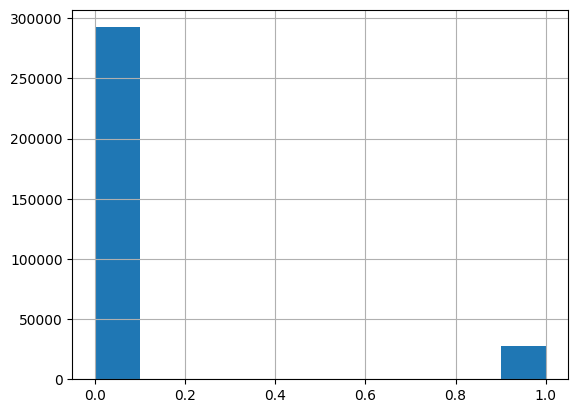

In [7]:
df_encoded['HeartDisease'].hist()

## Step 5: Data Split [2 points]

Use  `train_test_split` from Scikit-learn and split the Features and Label(Y) to 70% training subset and 30% test subset. Use the variable names as shown below

In [11]:
from sklearn.model_selection import train_test_split
### BEGIN SOLUTION


X = df_encoded.drop("HeartDisease", axis=1)
Y = df_encoded["HeartDisease"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.30, random_state=42
)




### END SOLUTION

## Step 6: Logistic Regression [2 points]



1.   Use  `LogisticRegression` from `sklearn.linear_model` and train a classification model named `model1`
2.   Predict the label for test data and store the predictions in a variable named `Y_test_Predicted`



If you run the model with default parameters, you will get convergence warning. Increase the `max_iter` parameter till the warning disappears! You should not get any warning.

In [12]:
from sklearn.linear_model import LogisticRegression
### BEGIN SOLUTION


model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, Y_train)

Y_test_Predicted = model1.predict(X_test)



### END SOLUTION

## Step 7: Confusion Matrix

In the latest version of Scikit-learn, confusion matrices are visualized using two functions: `confusion_matrix` and `ConfusionMatrixDisplay`.

*   The process involves first computing the matrix values with `confusion_matrix`,
*   then passing them to `ConfusionMatrixDisplay` for visualization.

```
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix(Y_test, ModelName.predict(X_test)))
disp.plot()
```


In older versions of Scikit-learn, we used the function `plot_confusion_matrix`. **That approach is now deprecated** and provided here only as a reference (not recommended anymore):
```
from sklearn.metrics import plot_confusion_matrix
plot_confusion_matrix(ModelName, X_test, Y_test)
```

Run the code below to get the confusion Matrix and other measures for the **test dataset.**

LGC result:
Accuracy:  0.9137993933645338
f1_score:  0.14917695473251028
Precision:  0.506993006993007
Recall:  0.08745476477683957


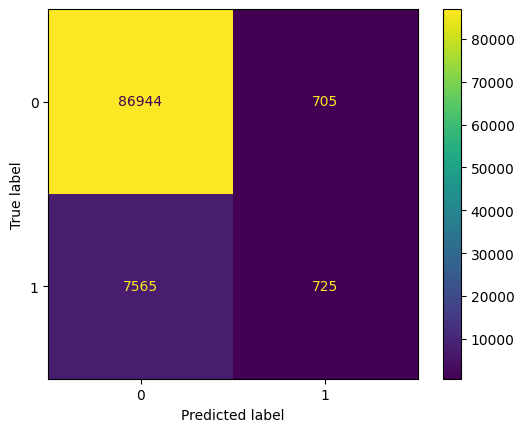

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

disp = ConfusionMatrixDisplay(confusion_matrix(Y_test,Y_test_Predicted ))
disp.plot()

print('LGC result:')
print('Accuracy: ',accuracy_score(Y_test,Y_test_Predicted))
print('f1_score: ',f1_score(Y_test,Y_test_Predicted))
print('Precision: ', precision_score(Y_test,Y_test_Predicted))
print('Recall: ', recall_score(Y_test,Y_test_Predicted))

##⚠️ Step 8: Something is Wrong!

At first glance, the **accuracy** of the model might look high 📈, but when you compare it with the **F1-score**, there’s a big gap. Why is that? Let’s dig in:

👉 If you look at the **confusion matrix**, most of the data belongs to people who are **not sick**. The model predicts those cases correctly, which boosts the accuracy. However, in the second row (**the sick people**), very few are predicted correctly ❌.

This happens because the dataset is **highly imbalanced** ⚖️. When one class (not sick) dominates the data, a naive model could simply predict **“not sick” for everyone** and still achieve a high overall accuracy — even though it completely fails at detecting sick people.

💡 That’s why we can’t trust accuracy alone for imbalanced datasets. Instead, we rely on metrics like the **F1-score**, which balances precision and recall. The F1-score ensures that the model is evaluated on its ability to correctly identify both **healthy people** ✅ and **sick people** ❤️‍🩹, not just the majority class.


## Step 9: Fix the issue [2 points]

When you run the following code, you will see that there is a parameter called `class_weight` which is `None`.

In [14]:
model1.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 1000,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

1.   Use  `LogisticRegression` from `sklearn.linear_model` and train a classification model named `model2` setting `class_weight='balanced'`. By setting this parameter, we are sampling from both classes (sick and not sick) consistantly and overcome the unbalanceness up to a certain point.
2.   Predict the label for test data and store the predictions in a variable named `Y_test_Predicted2`



If you run the model with default parameters, you will get convergence warning. Increase the `max_iter` parameter till the warning disappears! You should not get any warning.

In [15]:
from sklearn.linear_model import LogisticRegression
### BEGIN SOLUTION

model2 = LogisticRegression(class_weight="balanced", max_iter=1000)
model2.fit(X_train, Y_train)

Y_test_Predicted2 = model2.predict(X_test)



### END SOLUTION

## Step 10: Confusion Matrix revised

Run the following code block and confusion matrix should show up! You should see:

*   100% increase in f1-score and decrease in accuracy
*   On every row, the largest value is in the diagonal cell

In anotherword, model is learning instead of just saying not sick not sick!

LGC result:
Accuracy:  0.740908285473061
f1_score:  0.33776475289729585
Precision:  0.21675500085484697
Recall:  0.7646562123039807


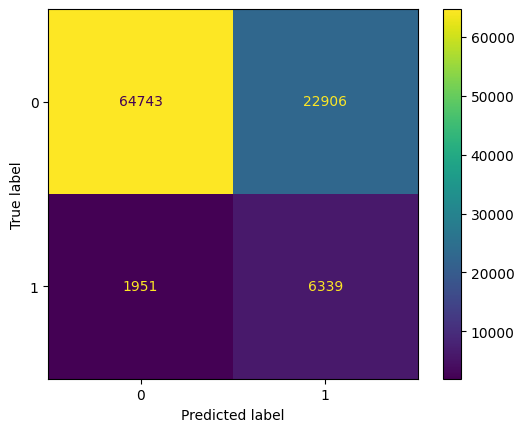

In [16]:
disp = ConfusionMatrixDisplay(confusion_matrix(Y_test,Y_test_Predicted2 ))
disp.plot()

print('LGC result:')
print('Accuracy: ',accuracy_score(Y_test,Y_test_Predicted2))
print('f1_score: ',f1_score(Y_test,Y_test_Predicted2))
print('Precision: ', precision_score(Y_test,Y_test_Predicted2))
print('Recall: ', recall_score(Y_test,Y_test_Predicted2))
